# 03 — Attention-DragonNet: Training the Debiased Neural Uplift Model

This notebook builds and trains the model that ties together both angles of
this demo:

- **Neural architecture with attention** — each feature is projected into
  its own embedding ("tokenized"), and a self-attention layer lets the
  model learn feature *interactions* (e.g. loyalty tier × price
  sensitivity) rather than relying on a plain MLP's entangled mixing or a
  tree's implicit splits.
- **Causal debiasing (IPW / doubly robust)** — a Dragonnet-style
  architecture: one shared representation feeds a propensity head and two
  potential-outcome heads, plus a *targeted regularization* term that bakes
  a doubly-robust correction directly into training.

We also add an **IPW-weighted T-learner** as a middle baseline, so the
final comparison shows a clean progression: naive → IPW-corrected →
full doubly-robust neural model.

In [1]:
import sys
sys.path.append("../src")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
import joblib

from simulate import simulate_promo_data
from evaluation import pehe, qini_curve, auuc
from model import (
    AttentionDragonNet, FeatureScaler, df_to_tensors, dragonnet_loss,
    predict_cate, predict_propensity, ALL_FEATURES,
)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
torch.manual_seed(0)

df = simulate_promo_data(n=20_000, seed=42)
feature_cols = ["loyalty_tier", "price_sensitivity", "lead_time_days",
                 "past_bookings", "device_mobile", "length_of_stay", "base_price"]
train_df, test_df = train_test_split(df, test_size=0.3, random_state=0)

with open("../data/baseline_results.json") as f:
    baseline_results = json.load(f)
baseline_results

{'s_learner_pehe': 12.620475580102026, 't_learner_pehe': 11.517443420962572}

## Middle baseline: IPW-weighted T-learner

Fit a propensity model with plain logistic regression, then re-fit the
T-learner's two LightGBM models with `sample_weight = 1/propensity`
(treated) or `1/(1-propensity)` (control). This directly corrects for
confounded assignment -- unlike the naive T-learner, similar units that
were *unlikely* to receive their observed treatment get up-weighted, which
is the whole IPW idea from the interview-prep doc, applied concretely.

In [2]:
prop_model = LogisticRegression(max_iter=1000)
prop_model.fit(train_df[feature_cols], train_df["treatment"])

train_propensity = prop_model.predict_proba(train_df[feature_cols])[:, 1].clip(0.02, 0.98)
train_w = np.where(
    train_df["treatment"] == 1, 1.0 / train_propensity, 1.0 / (1 - train_propensity)
)

ipw_model_1 = lgb.LGBMRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, verbose=-1)
ipw_model_0 = lgb.LGBMRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, verbose=-1)

treated_mask = train_df["treatment"] == 1
ipw_model_1.fit(train_df.loc[treated_mask, feature_cols], train_df.loc[treated_mask, "y"],
                 sample_weight=train_w[treated_mask.values])
ipw_model_0.fit(train_df.loc[~treated_mask, feature_cols], train_df.loc[~treated_mask, "y"],
                 sample_weight=train_w[(~treated_mask).values])

ipw_pred_ite = ipw_model_1.predict(test_df[feature_cols]) - ipw_model_0.predict(test_df[feature_cols])
ipw_pehe = pehe(test_df["ite_true"].values, ipw_pred_ite)
print(f"IPW-weighted T-learner PEHE: {ipw_pehe:.3f}  (naive T-learner was {baseline_results['t_learner_pehe']:.3f})")

IPW-weighted T-learner PEHE: 11.398  (naive T-learner was 11.517)


## The attention-Dragonnet model

Standardize features and the outcome, build the model, and train with the combined loss (outcome MSE + propensity BCE + targeted regularization).

In [3]:
scaler = FeatureScaler.fit(train_df)

x_cont_train, x_cat_train = df_to_tensors(train_df, scaler)
y_train = torch.tensor(scaler.scale_y(train_df["y"].values), dtype=torch.float32)
t_train = torch.tensor(train_df["treatment"].values, dtype=torch.float32)

x_cont_test, x_cat_test = df_to_tensors(test_df, scaler)

model = AttentionDragonNet(d_model=32, n_heads=4, n_layers=2)

# Epsilon (the targeted-regularization scalar) gets its own, much larger
# learning rate. It's a single scalar receiving a much smaller aggregate
# gradient than the rest of the network's thousands of parameters -- left
# at the same LR, it barely moves off its zero-init and the targeted
# regularization term ends up contributing nothing. Splitting it into its
# own param group is standard practice for Dragonnet-style epsilon layers.
other_params = [p for n, p in model.named_parameters() if n != "epsilon"]
optimizer = optim.Adam([
    {"params": other_params, "lr": 2e-3},
    {"params": [model.epsilon], "lr": 5e-2},
], weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=60)

n_epochs = 60
batch_size = 512
n_train = len(train_df)
history = {"total": [], "outcome": [], "propensity": [], "targeted_reg": []}

for epoch in range(n_epochs):
    model.train()
    perm = torch.randperm(n_train)
    epoch_losses = {"total": 0.0, "outcome_loss": 0.0, "propensity_loss": 0.0, "targeted_reg_loss": 0.0}
    n_batches = 0

    for start in range(0, n_train, batch_size):
        idx = perm[start:start + batch_size]
        xc = x_cont_train[idx]
        xcat = {f: v[idx] for f, v in x_cat_train.items()}
        yb, tb = y_train[idx], t_train[idx]

        logit, y0_pred, y1_pred = model(xc, xcat)
        loss, parts = dragonnet_loss(logit, y0_pred, y1_pred, model.epsilon, yb, tb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_losses["total"] += loss.item()
        for k, v in parts.items():
            epoch_losses[k] += v
        n_batches += 1

    scheduler.step()
    history["total"].append(epoch_losses["total"] / n_batches)
    history["outcome"].append(epoch_losses["outcome_loss"] / n_batches)
    history["propensity"].append(epoch_losses["propensity_loss"] / n_batches)
    history["targeted_reg"].append(epoch_losses["targeted_reg_loss"] / n_batches)

    if (epoch + 1) % 10 == 0:
        print(f"epoch {epoch+1:3d}  total={history['total'][-1]:.4f}  "
              f"outcome={history['outcome'][-1]:.4f}  propensity={history['propensity'][-1]:.4f}  "
              f"targeted_reg={history['targeted_reg'][-1]:.4f}")

epoch  10  total=0.8613  outcome=0.1054  propensity=0.6500  targeted_reg=0.1059


epoch  20  total=0.8350  outcome=0.0937  propensity=0.6475  targeted_reg=0.0938


epoch  30  total=0.8180  outcome=0.0850  propensity=0.6474  targeted_reg=0.0855


epoch  40  total=0.8131  outcome=0.0830  propensity=0.6469  targeted_reg=0.0832


epoch  50  total=0.8098  outcome=0.0814  propensity=0.6470  targeted_reg=0.0814


epoch  60  total=0.8079  outcome=0.0809  propensity=0.6461  targeted_reg=0.0809


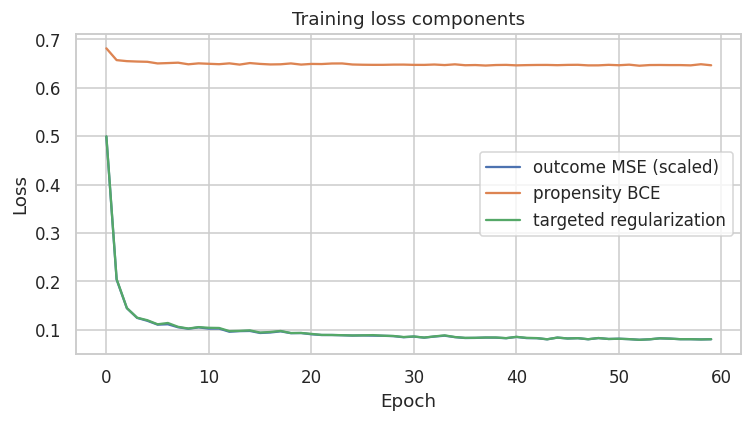

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history["outcome"], label="outcome MSE (scaled)")
ax.plot(history["propensity"], label="propensity BCE")
ax.plot(history["targeted_reg"], label="targeted regularization")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training loss components")
ax.legend()
plt.tight_layout()
plt.savefig("../figures/05_training_curves.png", bbox_inches="tight")
plt.show()

## Evaluate on the held-out test set

In [5]:
dragonnet_pred_ite = predict_cate(model, test_df, scaler)
dragonnet_pehe = pehe(test_df["ite_true"].values, dragonnet_pred_ite)

results_table = pd.DataFrame([
    {"model": "S-learner (naive)", "pehe": baseline_results["s_learner_pehe"]},
    {"model": "T-learner (naive)", "pehe": baseline_results["t_learner_pehe"]},
    {"model": "T-learner + IPW", "pehe": ipw_pehe},
    {"model": "Attention-DragonNet", "pehe": dragonnet_pehe},
])
results_table

,model,pehe
0,S-learner (naive),12.620476
1,T-learner (naive),11.517443
2,T-learner + IPW,11.398082
3,Attention-DragonNet,10.761373


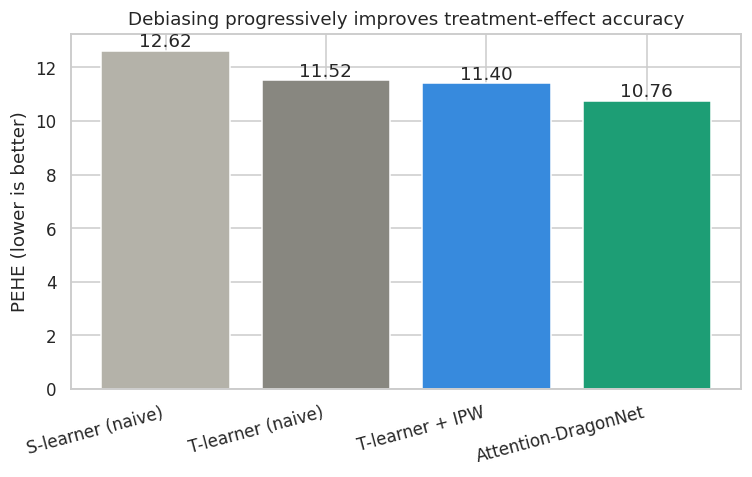

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
colors = ["#B4B2A9", "#888780", "#378ADD", "#1D9E75"]
bars = ax.bar(results_table["model"], results_table["pehe"], color=colors)
ax.set_ylabel("PEHE (lower is better)")
ax.set_title("Debiasing progressively improves treatment-effect accuracy")
for bar, val in zip(bars, results_table["pehe"]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.15, f"{val:.2f}", ha="center")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("../figures/06_pehe_comparison.png", bbox_inches="tight")
plt.show()

## Save all artifacts for the results notebook and the Streamlit app

In [7]:
import os
os.makedirs("../models", exist_ok=True)

torch.save(model.state_dict(), "../models/attention_dragonnet.pt")
with open("../models/scaler.json", "w") as f:
    json.dump(scaler.to_dict(), f, indent=2)

joblib.dump(ipw_model_1, "../models/ipw_t_learner_treated.joblib")
joblib.dump(ipw_model_0, "../models/ipw_t_learner_control.joblib")
joblib.dump(prop_model, "../models/propensity_logreg.joblib")

# Also persist the naive baselines from notebook 02 so the app doesn't need
# to retrain anything -- refit here quickly with the same settings for
# artifact completeness (identical to notebook 02's models).
s_features = feature_cols + ["treatment"]
s_model = lgb.LGBMRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, verbose=-1)
s_model.fit(train_df[s_features], train_df["y"])
joblib.dump(s_model, "../models/s_learner.joblib")

t_model_1 = lgb.LGBMRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, verbose=-1)
t_model_0 = lgb.LGBMRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, verbose=-1)
t_model_1.fit(train_df.loc[train_df.treatment == 1, feature_cols], train_df.loc[train_df.treatment == 1, "y"])
t_model_0.fit(train_df.loc[train_df.treatment == 0, feature_cols], train_df.loc[train_df.treatment == 0, "y"])
joblib.dump(t_model_1, "../models/t_learner_treated.joblib")
joblib.dump(t_model_0, "../models/t_learner_control.joblib")

results_table.to_json("../data/pehe_results.json", orient="records", indent=2)
test_df.to_parquet("../data/test_set.parquet")

print("all artifacts saved to ../models and ../data")

all artifacts saved to ../models and ../data
